# Re-Define the Model to memory ... must run!

In [1]:

"""
Stroke Lesion Segmentation (Dynamic Input Version)

This training script builds upon prior production and cropped variants but adds
support for arbitrary volumetric input sizes.  It automatically determines
the largest spatial dimensions present in a dataset and pads smaller volumes
so that all inputs share the same shape.  The script retains detailed
logging, memory monitoring, data augmentation and custom layers from the
previous versions while incorporating recommendations from the latest model
evaluation:

* Dice/boundary loss weights adjusted to emphasise boundary precision
* Over‑segmentation mitigation via adjustable decision threshold
* Slightly stronger augmentation (rotations/flips/gamma) when overfitting
  is suspected
* Tunable L2 regularisation and dropout rates
* Longer warm‑up and lower minimum learning rate

The batch size is fixed at 2, but input volumes may be of any shape as long
as the corresponding mask has identical dimensions.  All three spatial
dimensions are padded to the maximum observed size for consistent training.
"""

import os
import sys
import logging
from pathlib import Path

# ---- Environment (set BEFORE importing TensorFlow) ----
import os

# Keep: quiet logs
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

# Optional: better GPU allocator (helps reduce fragmentation on long runs)
# Works with TF 2.10+ built for CUDA 11/12.
os.environ["TF_GPU_ALLOCATOR"] = "cuda_malloc_async"

# Don't set for normal training:
# - CUDA_LAUNCH_BLOCKING=1  # debug-only; forces sync and can make training very slow
# - TF_XLA_FLAGS / XLA_FLAGS  # generally unnecessary on TF 2.20; can cause confusion
# - TF_ENABLE_ONEDNN_OPTS=0  # controls CPU-only kernels; leave default unless you need bit-for-bit CPU numerics


import tensorflow as tf

# See GPUs and enable memory growth (good practice)
gpus = tf.config.list_physical_devices("GPU")
print("Visible GPUs:", gpus)
for gpu in gpus:
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except Exception as e:
        print(f"Could not set memory growth on {gpu}: {e}")

# Optional: use all visible GPUs
strategy = tf.distribute.MirroredStrategy() if gpus else tf.distribute.get_strategy()
print("Strategy:", type(strategy).__name__)

# Build/compile inside the scope if you use strategy
# with strategy.scope():
#     model = ...
#     model.compile(...)



# ---------------------------------------------------------------------------
# Logging configuration
# ---------------------------------------------------------------------------
# Use two file handlers and one stream handler.  One file captures all
# high‑level events (INFO and above) and the other captures per‑process
# debugging output.  A console stream is kept for quick feedback.
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(name)s - %(levelname)s - %(message)s',
    handlers=[
        logging.FileHandler('logs/smart_sota_dynamic.log'),
        logging.FileHandler(f'logs/training_dynamic_{os.getpid()}.debug.log'),
        logging.StreamHandler()
    ]
)
logger = logging.getLogger('SmartSOTA_Dynamic')
logger.setLevel(logging.DEBUG)

# ---------------------------------------------------------------------------
# Imports with graceful degradation
# ---------------------------------------------------------------------------
try:
    import tensorflow as tf
    from tensorflow.keras import layers
    import numpy as np
    import nibabel as nib
    from scipy.ndimage import zoom, binary_dilation, rotate
    from sklearn.model_selection import KFold
    from skimage import measure
    import json
    import time
    import math
    import random
    import gc
    import psutil
    from functools import lru_cache
    from concurrent.futures import ThreadPoolExecutor
    logger.info("✅ All imports successful")
except ImportError as e:
    logger.critical(f"❌ Import failed: {e}")
    sys.exit(1)

# ---------------------------------------------------------------------------
# Runtime configuration
# ---------------------------------------------------------------------------
# Disable eager execution for performance and to avoid certain CUDNN issues.
tf.config.run_functions_eagerly(False)
logger.info(f"TensorFlow eager execution: {tf.executing_eagerly()}")

warnings_to_ignore = [UserWarning, DeprecationWarning, FutureWarning]
for w in warnings_to_ignore:
    tf.autograph.set_verbosity(0)
import warnings
for w in warnings_to_ignore:
    warnings.filterwarnings("ignore", category=w)
warnings.filterwarnings("ignore", module="nibabel")

logger.info(
    f"Environment verified:\n"
    f"- Python {sys.version}\n"
    f"- TensorFlow {tf.__version__}\n"
    f"- NumPy {np.__version__}\n"
    f"- GPU devices: {len(tf.config.list_physical_devices('GPU'))}"
)

# ---------------------------------------------------------------------------
# Training configuration
# ---------------------------------------------------------------------------
class DynamicTrainingConfig:
    """Configuration class supporting variable input shapes.

    The first call to `detect_input_shape` will populate INPUT_SHAPE based on
    observed dataset maxima.  All other hyperparameters may be tuned from
    outside to reflect recommendations from prior evaluations.
    """

    DATA_DIR: Path   = Path("/home/rbielski/SOOP/ds004889/acute_only/preprocessed/flair_acute_train")
    IMAGES_DIR: Path = DATA_DIR
    MASKS_DIR: Path  = DATA_DIR


    # The input shape will be set by detect_input_shape; default to None
    INPUT_SHAPE = None

    # Data split configuration
    VALIDATION_SPLIT = 0.15
    SMALL_LESION_THRESHOLD = 100

    # Training schedule
    BATCH_SIZE = 2
    INITIAL_EPOCH = 0
    TOTAL_EPOCHS = 200
    INITIAL_LR = 1e-4
    MIN_LR = 5e-7               # Lower minimum LR for potential late training plateaus
    WARMUP_EPOCHS = 15          # Extended warmup
    MAX_GRAD_NORM = 1.0

    # Model architecture
    BASE_FILTERS = 8
    DROPOUT_RATE = 0.55         # Balanced dropout for robustness
    L2_REG = 1.5e-3             # Moderate L2 regularisation
    MAMBA_DEPTH = 2
    SAM_HEADS = 4

    # Data augmentation
    AUGMENTATION_INTENSITY = 0.5
    SYNTHETIC_LESION_PROB = 0.3
    ROTATION_RANGE = 20         # Slightly larger range than original

    # Loss configuration (based on evaluation recommendations)
    USE_BOUNDARY_LOSS = True
    DICE_LOSS_WEIGHT = 0.4
    BOUNDARY_LOSS_WEIGHT = 0.6
    DEEP_SUPERVISION_WEIGHTS = [0.1, 0.2, 0.3]
    
    #Tweaks
    # Add these defaults anywhere among the other hyperparams:
    DICE_WEIGHT: float = 0.4
    BOUNDARY_WEIGHT: float = 0.6
    # inside class DynamicTrainingConfig:
    RESAMPLE_TO_TARGET = True   # resample both image & mask to INPUT_SHAPE[:-1]


    # Decision threshold for converting logits to binary masks
    DECISION_THRESHOLD = 0.5    # Raise threshold to mitigate over‑segmentation

    # Output directories
    MODEL_DIR = Path("/home/rbielski/stroke_cleaned/models/FLAIR_models")
    CALLBACKS_DIR = Path("callbacks/dynamic_production")

    def __init__(self):
        # Timestamp for saving model checkpoints
        self.timestamp = time.strftime("%Y%m%d_%H%M%S")
        self.MODEL_DIR.mkdir(parents=True, exist_ok=True)
        self.CALLBACKS_DIR.mkdir(parents=True, exist_ok=True)
        # Write config to JSON for reproducibility
        config_dict = {k: v for k, v in self.__dict__.items()
                      if not k.startswith('__') and not callable(v)}
        with open(self.MODEL_DIR / "config.json", "w") as f:
            json.dump(config_dict, f, indent=2, default=str)
        logger.info(
            f"📋 DynamicTrainingConfig initialised:\n"
            f"   Images directory: {self.IMAGES_DIR}\n"
            f"   Masks directory: {self.MASKS_DIR}\n"
            f"   Batch size: {self.BATCH_SIZE}\n"
            f"   Warmup epochs: {self.WARMUP_EPOCHS}\n"
            f"   Minimum LR: {self.MIN_LR}\n"
            f"   Dice/boundary weights: {self.DICE_LOSS_WEIGHT}:{self.BOUNDARY_LOSS_WEIGHT}\n"
        )

    @property
    def model_path(self) -> Path:
        return self.MODEL_DIR / f"smart_sota_dynamic_{self.timestamp}.keras"

    
    @property
    def checkpoint_path(self) -> Path:
        return self.CALLBACKS_DIR / "best_model_dynamic.weights.h5"



# ---------------------------------------------------------------------------
# Custom layers (identical to previous implementations)
# ---------------------------------------------------------------------------
# put this once near the top (same place you imported for losses)
try:
    from keras.saving import register_keras_serializable
except Exception:
    from tensorflow.keras.utils import register_keras_serializable  # fallback


@register_keras_serializable(package="custom")
class ResidualConvBlock(layers.Layer):
    """Residual block using LayerNorm (more stable than BN for very small batches)."""
    def __init__(self, filters, kernel_reg=None, **kwargs):
        super().__init__(**kwargs)
        self.filters = filters
        self.kernel_reg = kernel_reg

    def build(self, input_shape):
        self.conv1 = layers.Conv3D(self.filters, 3, padding='same',
                                   kernel_regularizer=self.kernel_reg)
        self.ln1 = layers.LayerNormalization(epsilon=1e-5)
        self.conv2 = layers.Conv3D(self.filters, 3, padding='same',
                                   kernel_regularizer=self.kernel_reg)
        self.ln2 = layers.LayerNormalization(epsilon=1e-5)
        self.dropout = layers.SpatialDropout3D(0.1)
        self.residual_conv = layers.Conv3D(self.filters, 1, padding='same')
        self.residual_ln = layers.LayerNormalization(epsilon=1e-5)
        super().build(input_shape)

    def call(self, inputs, training=None):
        x = self.conv1(inputs)
        x = self.ln1(x)
        x = tf.nn.relu(x)
        x = self.dropout(x, training=training)
        x = self.conv2(x)
        x = self.ln2(x)
        residual = self.residual_conv(inputs)
        residual = self.residual_ln(residual)
        return tf.nn.relu(x + residual)

    def get_config(self):
        config = super().get_config()
        config.update({
            "filters": self.filters,
            "kernel_reg": tf.keras.regularizers.serialize(self.kernel_reg)
                           if self.kernel_reg else None
        })
        return config


@register_keras_serializable(package="custom")
class VisionMambaBlock(layers.Layer):
    """Efficient vision Mamba block with dynamic input support"""
    def __init__(self, filters, kernel_size=3, expansion=2, **kwargs):
        super().__init__(**kwargs)
        self.filters = filters
        self.kernel_size = kernel_size
        self.expansion = expansion

    def build(self, input_shape):
        self.in_conv = layers.Conv3D(
            self.filters * self.expansion,
            1,
            use_bias=False,
            padding='same',
            data_format='channels_last')
        self.spatial_conv = layers.Conv3D(
            self.filters * self.expansion,
            self.kernel_size,
            padding='same',
            use_bias=False,
            data_format='channels_last')
        self.out_conv = layers.Conv3D(
            self.filters, 1,
            padding='same',
            data_format='channels_last')
        self.norm = layers.LayerNormalization()
        self.dropout = layers.SpatialDropout3D(0.1)
        super().build(input_shape)

    def call(self, inputs, training=None):
        x = self.in_conv(inputs)
        x = tf.nn.relu(x)
        x = self.spatial_conv(x)
        x = tf.cast(tf.nn.relu(x), inputs.dtype)
        x = self.dropout(x, training=training)
        x = self.out_conv(x)
        x = self.norm(x)
        return x + inputs

    def get_config(self):
        config = super().get_config()
        config.update({
            "filters": self.filters,
            "kernel_size": self.kernel_size,
            "expansion": self.expansion
        })
        return config

@register_keras_serializable(package="custom")
class SAM2Attention(layers.Layer):
    """Enhanced SAM2 attention with hierarchical memory banks"""
    def __init__(self, filters, heads, **kwargs):
        super().__init__(**kwargs)
        self.filters = filters
        self.heads = heads
        self.depth = filters // heads
        if filters % heads != 0:
            raise ValueError("Filters must be divisible by heads")

    def build(self, input_shape):
        self.query = layers.Conv3D(self.filters, 1, data_format='channels_last')
        self.key = layers.Conv3D(self.filters, 1, data_format='channels_last')
        self.value = layers.Conv3D(self.filters, 1, data_format='channels_last')
        self.out_conv = layers.Conv3D(input_shape[-1], 1, data_format='channels_last')
        self.memory_bank = self.add_weight(
            name='memory_bank',
            shape=(1, 1, 1, 1, self.filters),
            initializer='zeros',
            trainable=True
        )
        self.dropout = layers.SpatialDropout3D(0.1)
        super().build(input_shape)

    def call(self, inputs, training=None):
        batch_size = tf.shape(inputs)[0]
        height = tf.shape(inputs)[1]
        width = tf.shape(inputs)[2]
        depth_dim = tf.shape(inputs)[3]
        q = self.query(inputs)
        k = self.key(inputs)
        v = self.value(inputs)
        k = k + self.memory_bank
        v = v + self.memory_bank
        q = self._split_heads_safe(q, batch_size, height, width, depth_dim)
        k = self._split_heads_safe(k, batch_size, height, width, depth_dim)
        v = self._split_heads_safe(v, batch_size, height, width, depth_dim)
        dk = tf.cast(self.depth, q.dtype)
        attn_logits = tf.matmul(q, k, transpose_b=True)
        attn_logits = attn_logits / tf.math.sqrt(dk)
        attn_weights = tf.nn.softmax(attn_logits, axis=-1)
        attn_output = tf.matmul(attn_weights, v)
        attn_output = self._combine_heads_safe(attn_output, batch_size, height, width, depth_dim)
        output = self.out_conv(attn_output)
        output = self.dropout(output, training=training)
        return output + inputs

    def _split_heads_safe(self, x, batch_size, height, width, depth_dim):
        x = tf.reshape(x, [batch_size, height, width, depth_dim, self.heads, self.depth])
        return tf.transpose(x, perm=[0, 4, 1, 2, 3, 5])

    def _combine_heads_safe(self, x, batch_size, height, width, depth_dim):
        x = tf.transpose(x, perm=[0, 2, 3, 4, 1, 5])
        return tf.reshape(x, [batch_size, height, width, depth_dim, self.filters])

    def get_config(self):
        config = super().get_config()
        config.update({
            "filters": self.filters,
            "heads": self.heads
        })
        return config

# ---------------------------------------------------------------------------
# Build the segmentation model (UNet-like with your custom blocks)
# ---------------------------------------------------------------------------
def build_dynamic_model(config: DynamicTrainingConfig) -> tf.keras.Model:
    inputs = tf.keras.Input(shape=config.INPUT_SHAPE)  # (D,H,W,1)

    x = inputs
    skips = []
    filters = config.BASE_FILTERS

    # Encoder
    for _ in range(4):
        x = ResidualConvBlock(filters, kernel_reg=tf.keras.regularizers.l2(config.L2_REG))(x)
        x = VisionMambaBlock(filters)(x)
        skips.append(x)
        x = layers.MaxPool3D(pool_size=2)(x)
        filters *= 2

    # Bottleneck
    x = ResidualConvBlock(filters, kernel_reg=tf.keras.regularizers.l2(config.L2_REG))(x)
    x = SAM2Attention(filters, heads=config.SAM_HEADS)(x)

    # Decoder
    for d in reversed(range(4)):
        filters //= 2
        x = layers.UpSampling3D(size=2)(x)
        x = layers.Concatenate()([x, skips[d]])
        x = ResidualConvBlock(filters, kernel_reg=tf.keras.regularizers.l2(config.L2_REG))(x)
        x = VisionMambaBlock(filters)(x)

    # IMPORTANT: output logits (no activation). Dice in your loss applies sigmoid.
    # Build model – replace the head
    outputs = layers.Conv3D(1, kernel_size=1, activation="sigmoid", name="probs")(x)


    return tf.keras.Model(inputs=inputs, outputs=outputs, name="SmartSOTA_Dynamic")



# ---------------------------------------------------------------------------
# Utility functions for memory monitoring
# ---------------------------------------------------------------------------
def log_memory_usage(stage: str) -> None:
    process = psutil.Process(os.getpid())
    gb_used = process.memory_info().rss / 1024**3
    gpu_mem = []
    try:
        for i in range(4):
            alloc = tf.config.experimental.get_memory_info(f'GPU:{i}')
            gpu_mem.append(f"GPU{i}: {alloc['current']/1e9:.2f}GB")
    except Exception:
        gpu_mem = ["GPU mem tracking failed"]
    try:
        disk_usage = psutil.disk_usage('/')
        disk_free_gb = disk_usage.free / 1024**3
        disk_info = f"Disk: {disk_free_gb:.1f}GB free"
    except Exception:
        disk_info = "Disk: unavailable"
    logger.info(f"Memory at {stage}: CPU={gb_used:.2f}GB | {' | '.join(gpu_mem)} | {disk_info}")


# ---------------------------------------------------------------------------
# Dataset inspection and loading
# ---------------------------------------------------------------------------
from pathlib import Path
import numpy as np
import nibabel as nib
import gc



def detect_input_shape(data_dir: Path) -> tuple:
    """
    Determine the maximum spatial (D,H,W) across NIfTI volumes under `data_dir`,
    then round each dimension UP to the nearest multiple of 16.

    We consider any .nii.gz with at least 3 dims. If none are valid, an error is raised.
    Logs fall back to print() if a global `logger` isn't available.
    """
    import math
    import nibabel as nib

    log = globals().get("logger", None)
    def _info(msg: str):
        if log is not None:
            log.info(msg)
        else:
            print(msg)

    _info("🔍 Detecting input shape from dataset…")

    # Scan all NIfTI files under the root (Images/Masks are fine; we only read headers/shapes)
    image_files = list(data_dir.rglob("*.nii.gz"))
    max_shape = [0, 0, 0]
    invalid = []

    if not image_files:
        raise FileNotFoundError(f"No .nii.gz files found under {data_dir}")

    for f in image_files:
        try:
            img = nib.load(str(f))
            shp = img.shape
            # Need at least 3 spatial dims
            if len(shp) >= 3:
                for i in range(3):
                    max_shape[i] = max(max_shape[i], int(shp[i]))
            else:
                invalid.append(f"{f.name}: shape {shp} has fewer than 3 dims")
        except Exception as e:
            invalid.append(f"{f.name}: failed to load ({e})")

    if all(dim == 0 for dim in max_shape):
        details = ("Issues encountered:\n  - " + "\n  - ".join(invalid)) if invalid else "No details."
        raise RuntimeError(f"No valid 3-D NIfTI files found in {data_dir}. {details}")

    def _ceil16(x: int) -> int:
        return int(math.ceil(x / 16.0) * 16)

    rounded_shape = tuple(_ceil16(dim) for dim in max_shape)

    _info(
        f"📐 Detected max volume dimensions: {tuple(max_shape)} → "
        f"rounded up to: {rounded_shape}"
    )
    return rounded_shape


0
# --- Flexible loader: supports single-folder (preprocessed) or two-folder (raw) ---
import gc, re, json
import numpy as np
import nibabel as nib
from pathlib import Path

def load_generic_dataset(config: DynamicTrainingConfig):
    """
    Supports two layouts:

    (A) Single preprocessed folder (images & masks together):
        sub-XX_space-TRACE_desc-lesionAcute_img_prepped.nii.gz
        sub-XX_space-TRACE_desc-lesionAcute_mask_prepped.nii.gz

    (B) Two-folder layout:
        IMAGES_DIR: .../*.nii.gz   (any modality: FLAIR, DWI, T1w, etc.)
        MASKS_DIR : .../*.nii.gz

    Pairing is by a shared base key after stripping known suffixes.
    """
    import re, gc, logging
    from pathlib import Path
    import nibabel as nib
    import numpy as np

    logger = logging.getLogger(__name__)

    base      = config.DATA_DIR
    images_dir = getattr(config, "IMAGES_DIR", None)
    masks_dir  = getattr(config, "MASKS_DIR", None)

    # ---- Decide layout
    single_folder_mode = False
    if images_dir is None or masks_dir is None or str(images_dir) == str(base) or str(masks_dir) == str(base):
        single_folder_mode = True
        images_dir = Path(base) if images_dir is None else Path(images_dir)
        masks_dir  = images_dir
    else:
        images_dir, masks_dir = Path(images_dir), Path(masks_dir)

    # ---- Helpers
    def strip_ext(name: str) -> str:
        return name[:-7] if name.endswith(".nii.gz") else name

    # Keys for *_prepped files
    def prepped_key(stem: str) -> str:
        # remove _img_prepped or _mask_prepped only
        stem = stem.replace("_img_prepped", "")
        stem = stem.replace("_mask_prepped", "")
        return stem

    # Fallback patterns for raw-ish names
    IMG_PATTERNS = [
        r"_space-TRACE_desc-[^_]+_img(?:_prepped)?$",
        r"_rec-TRACE_dwi(?:_prepped)?$",
        r"_T1w(?:_prepped)?$",
        r"(?:_image|_img)(?:_prepped)?$"
    ]
    MSK_PATTERNS = [
        r"_space-TRACE_desc-[^_]+_mask(?:_prepped)?$",
        r"(?:_mask|_label|_seg)(?:_prepped)?$"
    ]

    def _strip_with_patterns(stem: str, pats) -> str:
        for p in pats:
            s = re.sub(p, "", stem)
            if s != stem:
                return s
        return stem

    def img_key(p: Path) -> str:
        stem = strip_ext(p.name)
        return prepped_key(stem) if stem.endswith("_img_prepped") else _strip_with_patterns(stem, IMG_PATTERNS)

    def msk_key(p: Path) -> str:
        stem = strip_ext(p.name)
        return prepped_key(stem) if stem.endswith("_mask_prepped") else _strip_with_patterns(stem, MSK_PATTERNS)

    # ---- Collect candidates
    if single_folder_mode:
        all_niis = sorted(images_dir.glob("*.nii.gz"))
        images = [p for p in all_niis if p.name.endswith("_img_prepped.nii.gz")]
        masks  = [p for p in all_niis if p.name.endswith("_mask_prepped.nii.gz")]
        logger.info(f"📁 Single-folder mode: {len(images)} images, {len(masks)} masks in {images_dir}")
    else:
        # Be liberal in two-folder mode: ingest everything; keys will filter.
        images = sorted(images_dir.glob("*.nii.gz"))
        masks  = sorted(masks_dir.glob("*.nii.gz"))
        logger.info(f"📂 Two-folder mode: images={len(images)} ({images_dir}), masks={len(masks)} ({masks_dir})")

    logger.info(f"Found {len(images)} image files and {len(masks)} mask files")

    img_map = {img_key(p): p for p in images}
    msk_map = {msk_key(p): p for p in masks}
    keys = sorted(set(img_map).intersection(msk_map.keys()))
    logger.info(f"🔑 Matched {len(keys)} image–mask pairs by key")

    if not keys:
        logger.error("No image–mask pairs matched. Example keys:")
        for k, v in list(img_map.items())[:5]:
            logger.error(f"  IMG key {k} -> {v.name}")
        for k, v in list(msk_map.items())[:5]:
            logger.error(f"  MSK key {k} -> {v.name}")
        raise RuntimeError("No pairs matched. Check filename patterns / directory paths.")

    # ---- Build pairs and detect lesion presence (fast header load)
    pairs, lesion_counts = [], []
    for k in keys:
        ip, mp = img_map[k], msk_map[k]
        try:
            mobj = nib.load(str(mp))
            has_lesion = bool(np.any(mobj.get_fdata(dtype=np.float32) > 0.0))
            lesion_counts.append(1 if has_lesion else 0)
            pairs.append((ip, mp))
        except Exception as e:
            logger.warning(f"Skipping {k}: {e}")
        finally:
            try: del mobj
            except: pass
            gc.collect()

    logger.info(f"📊 Ready pairs: {len(pairs)} | lesion-present ~{(np.mean(lesion_counts)*100 if lesion_counts else 0):.1f}%")
    return pairs, np.array(lesion_counts, dtype=np.int32)




def create_stratified_splits(pairs, lesion_presence, batch_size, test_size=0.1):
    """Generate train/validation splits compatible with batch size.

    We adapt the original function to ensure that each split contains a number
    of samples divisible by the batch size.  Stratification is performed
    based on lesion presence.
    """
    total_samples = len(pairs)
    test_samples = math.floor(total_samples * test_size)
    train_samples = total_samples - test_samples
    # Round down to nearest batch size
    test_samples = (test_samples // batch_size) * batch_size
    train_samples = total_samples - test_samples
    # Guarantee at least one batch in each split
    if test_samples < batch_size:
        test_samples = batch_size
        train_samples = total_samples - test_samples
    if train_samples < batch_size:
        train_samples = batch_size
        test_samples = total_samples - train_samples
    logger.info(
        f"🧮 Dataset split: Train={train_samples}"
        f" ({train_samples/total_samples*100:.1f}%), "
        f"Validation={test_samples} ({test_samples/total_samples*100:.1f}%)"
    )
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    for train_idx, test_idx in kf.split(pairs, lesion_presence):
        if len(test_idx) >= test_samples:
            test_idx = test_idx[:test_samples]
            break
    train_pairs = [pairs[i] for i in train_idx]
    test_pairs = [pairs[i] for i in test_idx]
    train_lesions = np.mean([lesion_presence[i] for i in train_idx])
    test_lesions = np.mean([lesion_presence[i] for i in test_idx])
    logger.info(
        f"⚖️ Lesion representation: Train={train_lesions*100:.1f}%, "
        f"Validation={test_lesions*100:.1f}%"
    )
    return train_pairs, test_pairs

def pad_and_center_crop(volume: np.ndarray, target_shape: tuple) -> np.ndarray:
    """
    Symmetrically pad (if smaller) or center-crop (if larger) a 3D volume to target_shape.
    Works for both images (float) and masks (binary/float). No interpolation is used.
    """
    assert volume.ndim == 3, f"Expected 3D volume, got {volume.ndim}D"
    z, y, x = volume.shape
    tz, ty, tx = target_shape
    out = volume

    # Center-crop if needed
    if z > tz:
        start = (z - tz) // 2
        out = out[start:start+tz, :, :]
        z = tz
    if y > ty:
        start = (y - ty) // 2
        out = out[:, start:start+ty, :]
        y = ty
    if x > tx:
        start = (x - tx) // 2
        out = out[:, :, start:start+tx]
        x = tx

    # Symmetric pad if needed
    pad_z = max(0, tz - z)
    pad_y = max(0, ty - y)
    pad_x = max(0, tx - x)
    if pad_z or pad_y or pad_x:
        pz0, pz1 = pad_z // 2, pad_z - pad_z // 2
        py0, py1 = pad_y // 2, pad_y - pad_y // 2
        px0, px1 = pad_x // 2, pad_x - pad_x // 2
        out = np.pad(out, ((pz0, pz1), (py0, py1), (px0, px1)), mode="constant", constant_values=0)
    return out

# --- Center-slice helpers (shared crop/pad for image & mask) -----------------
def compute_center_slices(in_shape, out_shape):
    """
    Return input slices that pick the centered sub-volume when cropping, or the
    full axis when padding. Use these slices for BOTH image and mask.
    """
    inD, inH, inW = in_shape
    outD, outH, outW = out_shape
    slices = []
    for i_len, o_len in zip((inD, inH, inW), (outD, outH, outW)):
        if i_len >= o_len:
            start = (i_len - o_len) // 2
            end   = start + o_len
            slices.append(slice(start, end))
        else:
            # padding case: take the whole input on that axis
            slices.append(slice(0, i_len))
    return tuple(slices)  # (sd, sh, sw)

def apply_center_crop_or_pad(vol, in_slices, out_shape):
    """
    Apply the provided input slices, then center-pad into out_shape.
    Use the SAME in_slices for image and mask to guarantee identical transform.
    """
    sub = vol[in_slices[0], in_slices[1], in_slices[2]]
    out = np.zeros(out_shape, dtype=vol.dtype)
    # center place the 'sub' into out
    offs = tuple((o - s) // 2 for s, o in zip(sub.shape, out_shape))
    out[
        offs[0]:offs[0]+sub.shape[0],
        offs[1]:offs[1]+sub.shape[1],
        offs[2]:offs[2]+sub.shape[2],
    ] = sub
    return out.astype(np.float32)


# ---------------------------------------------------------------------------
# Data generator (no augmentations). Only resampling (optional) + center crop/pad.
# ---------------------------------------------------------------------------
import gc
from functools import lru_cache

import nibabel as nib
import numpy as np
import psutil
from scipy.ndimage import zoom
import tensorflow as tf

@lru_cache(maxsize=128)
def _load_vol_canonical(path: str) -> np.ndarray:
    """Load NIfTI as RAS-canonical and return float32 array."""
    img = nib.load(path)
    img = nib.as_closest_canonical(img)  # standardize orientation
    return img.get_fdata().astype(np.float32)

def _load_image(path: str) -> np.ndarray:
    return _load_vol_canonical(path)

def _load_mask_bin(path: str) -> np.ndarray:
    return (_load_vol_canonical(path) > 0.5).astype(np.float32)

def _center_crop_or_pad_volume(volume: np.ndarray, target_shape: tuple) -> np.ndarray:
    """
    Center-crop or pad a 3D volume to the target_shape.
    Works for both images (float) and masks (binary/float). No interpolation is used.
    """
    assert volume.ndim == 3, f"Expected 3D volume, got {volume.ndim}D"
    z, y, x = volume.shape
    tz, ty, tx = target_shape

    # Center-crop if larger
    if z > tz:
        start = (z - tz) // 2
        volume = volume[start:start+tz, :, :]
    if y > ty:
        start = (y - ty) // 2
        volume = volume[:, start:start+ty, :]
    if x > tx:
        start = (x - tx) // 2
        volume = volume[:, :, start:start+tx]

    # Pad if smaller
    pad_z = max(0, tz - z)
    pad_y = max(0, ty - y)
    pad_x = max(0, tx - x)
    if pad_z > 0 or pad_y > 0 or pad_x > 0:
        padding = ((pad_z//2, pad_z-pad_z//2), (pad_y//2, pad_y-pad_y//2), (pad_x//2, pad_x-pad_x//2))
        volume = np.pad(volume, padding, mode="constant", constant_values=0)

    return volume.astype(np.float32)

def _load_and_preprocess_image(path: str, target_shape: tuple) -> np.ndarray:
    """Load and preprocess a single image volume."""
    volume = _load_image(path)
    return _center_crop_or_pad_volume(volume, target_shape)

def _load_and_preprocess_mask(path: str, target_shape: tuple) -> np.ndarray:
    """Load and preprocess a single mask volume."""
    volume = _load_mask_bin(path)
    return _center_crop_or_pad_volume(volume, target_shape)

def _generate_batch(pairs, target_shape):
    """Generate a batch of image and mask pairs."""
    for img_path, msk_path in pairs:
        img = _load_and_preprocess_image(img_path, target_shape)
        msk = _load_and_preprocess_mask(msk_path, target_shape)
        yield img, msk

# ---------------------------------------------------------------------------
# Data generator with optional augmentations for training
# ---------------------------------------------------------------------------
class DynamicDataGenerator(tf.keras.utils.Sequence):
    """Dynamic data generator for 3D medical volumes with optional augmentation.
    
    Implements the Keras Sequence interface for memory-efficient loading
    and preprocessing of 3D medical image volumes and their corresponding masks.
    """
    
    def __init__(self, pairs, config, is_training=False):
        """Initialize the generator with pairs of image/mask paths and config.
        
        Args:
            pairs: List of (image_path, mask_path) tuples.
            config: DynamicTrainingConfig object with parameters.
            is_training: If True, apply augmentation.
        """
        self.pairs = pairs
        self.config = config
        self.is_training = is_training
        self.batch_size = config.BATCH_SIZE
        self.target_shape = config.INPUT_SHAPE[:-1]  # Remove channel dim
        
        # Shuffle at initialization
        if self.is_training:
            random.shuffle(self.pairs)
    
    def __len__(self):
        """Return the number of batches per epoch."""
        return math.ceil(len(self.pairs) / self.batch_size)
    
    def __getitem__(self, idx):
        """Get a batch of data."""
        batch_pairs = self.pairs[idx * self.batch_size:(idx + 1) * self.batch_size]
        batch_x = np.zeros((len(batch_pairs), *self.config.INPUT_SHAPE), dtype=np.float32)
        batch_y = np.zeros((len(batch_pairs), *self.config.INPUT_SHAPE), dtype=np.float32)
        
        for i, (img_path, msk_path) in enumerate(batch_pairs):
            # Load and preprocess image and mask
            img = _load_and_preprocess_image(str(img_path), self.target_shape)
            msk = _load_and_preprocess_mask(str(msk_path), self.target_shape)
            
            # Apply augmentations if in training mode
            if self.is_training and self.config.AUGMENTATION_INTENSITY > 0:
                img, msk = self._augment(img, msk)
            
            # Add channel dimension
            batch_x[i, ..., 0] = img
            batch_y[i, ..., 0] = msk
            
        return batch_x, batch_y
    
    def on_epoch_end(self):
        """Called at the end of each epoch."""
        if self.is_training:
            random.shuffle(self.pairs)
    
    def _augment(self, image, mask):
        """Apply augmentations to image and mask."""
        # Skip augmentation based on probability
        if random.random() > self.config.AUGMENTATION_INTENSITY:
            return image, mask
        
        # Random flips
        if random.random() > 0.5:
            image = np.flip(image, axis=0)
            mask = np.flip(mask, axis=0)
        if random.random() > 0.5:
            image = np.flip(image, axis=1)
            mask = np.flip(mask, axis=1)
            
        # Random rotation (limited to rotation_range degrees)
        if random.random() > 0.7:
            angle = random.uniform(-self.config.ROTATION_RANGE, self.config.ROTATION_RANGE)
            # Random rotation axis (0, 1, or 2)
            axis = random.randint(0, 2)
            axes = [(0, 1), (0, 2), (1, 2)][axis]
            image = rotate(image, angle, axes=axes, reshape=False, order=1, mode='constant')
            mask = rotate(mask, angle, axes=axes, reshape=False, order=0, mode='constant')
            # Ensure mask remains binary
            mask = (mask > 0.5).astype(np.float32)
        
        # Random gamma correction (image only)
        if random.random() > 0.8:
            gamma = random.uniform(0.7, 1.3)
            image_max = image.max()
            if image_max > 0:
                image = np.power(image / image_max, gamma) * image_max
        
        return image, mask

# Optional memory monitoring callback for training
class MemoryMonitoringCallback(tf.keras.callbacks.Callback):
    """Callback to monitor memory usage during training."""
    
    def __init__(self, log_frequency=5):
        super().__init__()
        self.log_frequency = log_frequency
    
    def on_epoch_end(self, epoch, logs=None):
        if epoch % self.log_frequency == 0:
            log_memory_usage(f"epoch_{epoch}")

# Define serializable loss functions for model saving/loading
def dice_coefficient(y_true, y_pred):
    """Dice coefficient metric for training and evaluation."""
    smooth = 1e-6
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth)

def make_combined_loss(alpha=0.4, beta=0.6):
    """Create a combined loss with configurable weights."""
    def loss_fn(y_true, y_pred):
        # Binary cross-entropy loss
        bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
        
        # Dice loss (1 - dice coefficient)
        dice = 1.0 - dice_coefficient(y_true, y_pred)
        
        # Weighted combination
        return alpha * dice + beta * bce
    
    return loss_fn

2025-10-14 10:32:00.509383: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-10-14 10:32:00.509412: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-10-14 10:32:00.510473: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Visible GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')
Strategy: MirroredStrategy
Strategy: MirroredStrategy


2025-10-14 10:32:02,092 - SmartSOTA_Dynamic - INFO - ✅ All imports successful
2025-10-14 10:32:02,093 - SmartSOTA_Dynamic - INFO - TensorFlow eager execution: True
2025-10-14 10:32:02,094 - SmartSOTA_Dynamic - INFO - Environment verified:
- Python 3.10.14 | packaged by conda-forge | (main, Mar 20 2024, 12:45:18) [GCC 12.3.0]
- TensorFlow 2.15.1
- NumPy 1.25.2
- GPU devices: 2
2025-10-14 10:32:02,093 - SmartSOTA_Dynamic - INFO - TensorFlow eager execution: True
2025-10-14 10:32:02,094 - SmartSOTA_Dynamic - INFO - Environment verified:
- Python 3.10.14 | packaged by conda-forge | (main, Mar 20 2024, 12:45:18) [GCC 12.3.0]
- TensorFlow 2.15.1
- NumPy 1.25.2
- GPU devices: 2


# Re-Test on Held Out validation set from the training

In [ ]:
import numpy as np, json, math, os
from pathlib import Path

# --- tiny helpers (per-sample, not per-batch) ---
def dice_hard_np(y_true, y_bin, eps=1e-6):
    y_true = y_true.astype(np.float32); y_bin = (y_bin > 0).astype(np.float32)
    inter = (y_true*y_bin).sum()
    denom = y_true.sum() + y_bin.sum()
    return (2*inter + eps)/(denom + eps)

def binarize(prob, thr): return (prob >= thr).astype(np.uint8)

def postprocess_3d(mask_bin, min_cc=0, closing_iter=0):
    from scipy.ndimage import label, binary_closing, generate_binary_structure
    out = mask_bin.astype(np.uint8).copy()
    if closing_iter > 0:
        s = generate_binary_structure(3, 1)
        for _ in range(closing_iter): out = binary_closing(out, structure=s).astype(np.uint8)
    if min_cc > 0:
        s = generate_binary_structure(3, 1)
        lbl, n = label(out, structure=s)
        if n > 0:
            sizes = np.bincount(lbl.ravel())
            remove_ids = [i for i in np.where(sizes < min_cc)[0] if i != 0]
            if remove_ids: out[np.isin(lbl, remove_ids)] = 0
    return out

def logit(p, eps=1e-6): p = np.clip(p, eps, 1-eps); return np.log(p/(1-p))
def sigmoid(x): return 1/(1+np.exp(-x))

# --- get probs & truths if not already computed in this session ---
if 'probs' not in globals() or 'truths' not in globals():
    print("Collecting val probs/truths...")
    # Use training data directory for validation split
    from pathlib import Path
    TRAIN_DIR = Path("/home/rbielski/SOOP/ds004889/acute_only/preprocessed/flair_acute_train")     ### Change to your training data path
    cfg = DynamicTrainingConfig()
    cfg.DATA_DIR = TRAIN_DIR
    cfg.INPUT_SHAPE = detect_input_shape(cfg.DATA_DIR) + (1,)
    pairs, lesion_presence = load_generic_dataset(cfg)
    _, val_pairs = create_stratified_splits(pairs, lesion_presence, batch_size=cfg.BATCH_SIZE, test_size=cfg.VALIDATION_SPLIT)
    val_gen = DynamicDataGenerator(val_pairs, cfg, is_training=False)
    import tensorflow as tf
    from tensorflow.keras.models import load_model

    # Check available GPUs
    gpus = tf.config.list_physical_devices('GPU')
    print("Available GPUs:", gpus)
    if gpus:
        tf.config.set_soft_device_placement(False)
        tf.debugging.set_log_device_placement(True)
    else:
        print("⚠️ No GPUs detected by TensorFlow. Predictions will run on CPU.")

    # Resolve execution device
    logical_gpus = tf.config.experimental.list_logical_devices('GPU')
    device_name = logical_gpus[0].name if logical_gpus else ('/GPU:0' if gpus else '/CPU:0')
    print(f"Routing TensorFlow ops to: {device_name}")

    # Load the full model from .keras file (not weights)
    model_path = Path("/home/rbielski/stroke_cleaned/models/FLAIR_models/smart_sota_dynamic_20251008_114447.keras")   ### Change to your model path
    if not model_path.exists():
        raise FileNotFoundError(f"Model file not found: {model_path}")
    with tf.device(device_name):
        model = load_model(str(model_path), compile=False)
        model.compile(optimizer="adam", loss="binary_crossentropy", metrics=[dice_coefficient])

    all_probs, all_truths = [], []

    with tf.device(device_name):
        for i in range(len(val_gen)):
            X, y = val_gen[i]
            X_tensor = tf.convert_to_tensor(X)
            preds = model(X_tensor, training=False)
            all_probs.append(tf.cast(preds, tf.float32).numpy())
            all_truths.append(y.astype(np.float32))

    probs  = np.concatenate(all_probs, axis=0)   # (N,D,H,W,1)
    truths = np.concatenate(all_truths, axis=0)  # (N,D,H,W,1)
print("Using arrays:", probs.shape, truths.shape)

N = truths.shape[0]

# 1) Pure threshold grid (no post-proc), dense
th_grid = np.linspace(0.20, 0.99, 80)
best = (-1.0, None)
for t in th_grid:
    scores = [dice_hard_np(truths[i,...,0], binarize(probs[i,...,0], t)) for i in range(N)]
    m = float(np.mean(scores))
    if m > best[0]: best = (m, float(t))
print(f"[No PP] best mean hard-Dice={best[0]:.4f} @ t={best[1]:.3f}")

# 2) Joint grid: threshold × min_cc × closing
fine_th = np.linspace(max(0.40, best[1]-0.25), min(0.99, best[1]+0.25), 60)
min_cc_grid = [0, 25, 50, 100, 150, 250, 400, 600, 1000]
clos_grid   = [0, 1, 2, 3]
best_joint = (-1.0, None, None, None)  # (mean, t, min_cc, clos)
for t in fine_th:
    for mcc in min_cc_grid:
        for clos in clos_grid:
            scores = []
            for i in range(N):
                mb = binarize(probs[i,...,0], t)
                mb = postprocess_3d(mb, min_cc=mcc, closing_iter=clos)
                scores.append(dice_hard_np(truths[i,...,0], mb))
            m = float(np.mean(scores))
            if m > best_joint[0]:
                best_joint = (m, float(t), int(mcc), int(clos))
print(f"[Grid PP] best mean={best_joint[0]:.4f} @ t={best_joint[1]:.3f}, min_cc={best_joint[2]}, closing={best_joint[3]}")

# 3) Temperature scaling + threshold (probability sharpening; no retraining)
T_grid  = np.linspace(0.6, 1.5, 19)  # T<1 sharpens, T>1 smooths
th_grid2= np.linspace(0.30, 0.95, 66)
best_temp = (-1.0, None, None)
logits = logit(probs[...,0])
for T in T_grid:
    pT = sigmoid(logits / T)[..., None]  # back to shape (...,1)
    for t in th_grid2:
        scores = [dice_hard_np(truths[i,...,0], binarize(pT[i,...,0], t)) for i in range(N)]
        m = float(np.mean(scores))
        if m > best_temp[0]: best_temp = (m, float(T), float(t))
print(f"[Temp] best mean={best_temp[0]:.4f} @ T={best_temp[1]:.2f}, t={best_temp[2]:.3f}")

# 4) Oracle per-case best threshold (upper bound for tuning on this val set)
oracle_ths = np.linspace(0.2, 0.99, 80)
oracle_scores = []
for i in range(N):
    best_i = max(dice_hard_np(truths[i,...,0], binarize(probs[i,...,0], t)) for t in oracle_ths)
    oracle_scores.append(best_i)
print(f"[Oracle per-case] mean upper bound={np.mean(oracle_scores):.4f}, median={np.median(oracle_scores):.4f}")

# Save summary
cfg = DynamicTrainingConfig()  # only to get the callbacks dir
# FLAIR-specific callbacks folder to avoid clobbering DWI outputs
CAL_DIR_FLAIR = Path("/home/rbielski/stroke_cleaned/callbacks/dynamic_production/FLAIR")
out = CAL_DIR_FLAIR / "val_threshold_tuning.json"
summary = {
    "no_postproc": {"best_mean": best[0], "t": best[1]},
    "grid_postproc": {"best_mean": best_joint[0], "t": best_joint[1],
                      "min_cc": best_joint[2], "closing": best_joint[3]},
    "temperature": {"best_mean": best_temp[0], "T": best_temp[1], "t": best_temp[2]},
    "oracle_upper_bound": {"mean": float(np.mean(oracle_scores)),
                           "median": float(np.median(oracle_scores))},
    "N": int(N),
}
out.parent.mkdir(parents=True, exist_ok=True)
out.write_text(json.dumps(summary, indent=2))
print("Wrote:", out, "\n", json.dumps(summary, indent=2))

2025-10-09 13:36:49,026 - SmartSOTA_Dynamic - INFO - 📋 DynamicTrainingConfig initialised:
   Images directory: /home/rbielski/SOOP/ds004889/acute_only/preprocessed/flair_acute_train
   Masks directory: /home/rbielski/SOOP/ds004889/acute_only/preprocessed/flair_acute_train
   Batch size: 2
   Warmup epochs: 15
   Minimum LR: 5e-07
   Dice/boundary weights: 0.4:0.6

2025-10-09 13:36:49,026 - SmartSOTA_Dynamic - INFO - 🔍 Detecting input shape from dataset…


2025-10-09 13:36:49,554 - SmartSOTA_Dynamic - INFO - 📐 Detected max volume dimensions: (512, 512, 32) → rounded up to: (512, 512, 32)
2025-10-09 13:36:49,560 - __main__ - INFO - 📁 Single-folder mode: 680 images, 680 masks in /home/rbielski/SOOP/ds004889/acute_only/preprocessed/flair_acute_train
2025-10-09 13:36:49,561 - __main__ - INFO - Found 680 image files and 680 mask files
2025-10-09 13:36:49,562 - __main__ - INFO - 🔑 Matched 680 image–mask pairs by key
2025-10-09 13:38:16,745 - __main__ - INFO - 📊 Ready pairs: 680 | lesion-present ~99.9%
2025-10-09 13:38:16,745 - SmartSOTA_Dynamic - INFO - 🧮 Dataset split: Train=578 (85.0%), Validation=102 (15.0%)
2025-10-09 13:38:16,746 - SmartSOTA_Dynamic - INFO - ⚖️ Lesion representation: Train=99.8%, Validation=100.0%


Available GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
Routing TensorFlow ops to: /device:GPU:0
Using arrays: (102, 512, 512, 32, 1) (102, 512, 512, 32, 1)
[No PP] best mean hard-Dice=0.0735 @ t=0.200
[Grid PP] best mean=0.0731 @ t=0.400, min_cc=1000, closing=0
[Temp] best mean=0.0735 @ T=1.50, t=0.300


2025-10-10 04:56:25,821 - SmartSOTA_Dynamic - INFO - 📋 DynamicTrainingConfig initialised:
   Images directory: /home/rbielski/SOOP/ds004889/acute_only/preprocessed/flair_acute_train
   Masks directory: /home/rbielski/SOOP/ds004889/acute_only/preprocessed/flair_acute_train
   Batch size: 2
   Warmup epochs: 15
   Minimum LR: 5e-07
   Dice/boundary weights: 0.4:0.6



[Oracle per-case] mean upper bound=0.0799, median=0.0118
Wrote: callbacks/dynamic_production/val_threshold_tuning.json 
 {
  "no_postproc": {
    "best_mean": 0.07352109626977205,
    "t": 0.2
  },
  "grid_postproc": {
    "best_mean": 0.07310832392081479,
    "t": 0.4,
    "min_cc": 1000,
    "closing": 0
  },
  "temperature": {
    "best_mean": 0.07349368756560098,
    "T": 1.5,
    "t": 0.3
  },
  "oracle_upper_bound": {
    "mean": 0.07987771263880591,
    "median": 0.011819198527577419
  },
  "N": 102
}


# Need to prep the TEST DATA the same way we did the training data 

Found: images=198, masks=155, pairs=155
TARGET_SHAPE (from train meta): (512, 512, 32)
Will write metadata to: /home/rbielski/SOOP/ds004889/acute_only/preprocessed/flair_acute_test/preprocess_meta.json
Done. Wrote 155 preprocessed pairs to: /home/rbielski/SOOP/ds004889/acute_only/preprocessed/flair_acute_test
Done. Wrote 155 preprocessed pairs to: /home/rbielski/SOOP/ds004889/acute_only/preprocessed/flair_acute_test


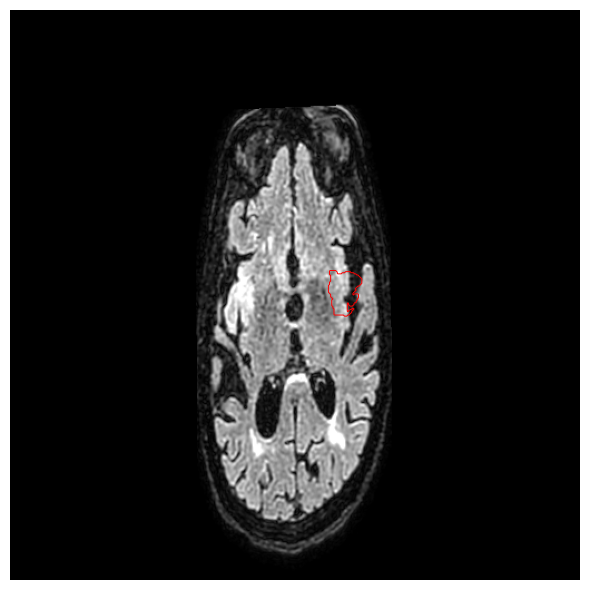

In [3]:
# ===================== Preprocess SOOP Acute Test Set (FLAIR) =====================
# - Pairs: strip "_FLAIR" (images); strip "_space-TRACE_desc-lesionAcute_mask" (masks)
# - Target shape: USE TRAIN META if available; else cap + ceil16 to MAX_TARGET_SHAPE
# - Prep: optional resample (img=linear, mask=nearest), then shared center crop/pad
# - Normalize images (inside non-zero); masks -> binary {0,1}

from pathlib import Path
import os, math, logging, json, gc
import numpy as np
import nibabel as nib
from scipy.ndimage import zoom

# ---------------------------- CONFIG -----------------------------------------
IMAGES_DIR = Path("/home/rbielski/SOOP/ds004889/acute_only/FLAIR_images/test")
MASKS_DIR  = Path("/home/rbielski/SOOP/ds004889/acute_only/Acute_mask/test")
OUT_DIR    = Path("/home/rbielski/SOOP/ds004889/acute_only/preprocessed/flair_acute_test")

RESAMPLE_TO_TARGET = False   # True -> resample to TARGET_SHAPE before crop/pad
SAVE_AFFINE_FROM = "image"   # "image" or "mask": which affine/header to keep when saving

OUT_DIR.mkdir(parents=True, exist_ok=True)
logging.getLogger("nibabel").setLevel(logging.ERROR)

# ------------------------ Pairing rules (SOOP naming; same as train) ---------
def _img_key(name: str) -> str:
    stem = name[:-7] if name.endswith(".nii.gz") else name
    return stem.replace("_FLAIR", "")

def _msk_key(name: str) -> str:
    s = name[:-7] if name.endswith(".nii.gz") else name
    return s.replace("_space-TRACE_desc-lesionAcute_mask", "")

def build_pairs(images_dir: Path, masks_dir: Path):
    imgs = { _img_key(p.name): p for p in sorted(images_dir.glob("*.nii.gz")) if "mask" not in p.name }
    msks = { _msk_key(p.name): p for p in sorted(masks_dir.glob("*.nii.gz")) if "mask" in p.name }
    keys = sorted(set(imgs) & set(msks))
    return [(imgs[k], msks[k]) for k in keys], len(imgs), len(msks), len(keys)

pairs, n_img, n_msk, n_pair = build_pairs(IMAGES_DIR, MASKS_DIR)
print(f"Found: images={n_img}, masks={n_msk}, pairs={n_pair}")
if n_pair == 0:
    raise RuntimeError("No pairs found. Check _img_key/_msk_key rules and directories.")

# ----------------------- Robust 3-D loader & helpers --------------------------
def ensure_3d(vol: np.ndarray) -> np.ndarray:
    v = np.asarray(vol)
    while v.ndim > 3 and v.shape[-1] == 1:
        v = v[..., 0]
    if v.ndim != 3:
        raise ValueError(f"Expected 3-D or 4-D with trailing singleton, got shape {vol.shape}")
    return v.astype(np.float32)

def load_nii_3d(path: Path):
    nii = nib.load(str(path))
    arr = nii.get_fdata()
    arr3d = ensure_3d(arr)
    return arr3d, nii

def ceil16(x: int) -> int:
    return int(math.ceil(x / 16.0) * 16)

# Cap to match training prep behaviour
MAX_TARGET_SHAPE = (512, 512, 32)

def detect_target_shape(pairs) -> tuple[int,int,int]:
    maxD = maxH = maxW = 0
    for img_p, _ in pairs:
        try:
            arr, _ = load_nii_3d(img_p)
            d, h, w = arr.shape
            maxD, maxH, maxW = max(maxD, int(d)), max(maxH, int(h)), max(maxW, int(w))
        except Exception:
            pass
    if min(maxD, maxH, maxW) == 0:
        raise RuntimeError("Could not determine target shape (no valid 3-D NIfTI).")
    raw_max = (maxD, maxH, maxW)
    capped = tuple(min(raw, cap) for raw, cap in zip(raw_max, MAX_TARGET_SHAPE))
    target = tuple(ceil16(dim) for dim in capped)
    print(f"Detected raw maxima: {raw_max} → capped: {capped} → final target: {target}")
    return target

# Prefer train meta to enforce identical target shape across splits
TRAIN_META = Path("/home/rbielski/SOOP/ds004889/acute_only/preprocessed/flair_acute_train/preprocess_meta.json")
if TRAIN_META.exists():
    meta = json.loads(TRAIN_META.read_text())
    TARGET_SHAPE = tuple(meta.get("target_shape", ()))
    if not TARGET_SHAPE:
        TARGET_SHAPE = detect_target_shape(pairs)
    print("TARGET_SHAPE (from train meta):", TARGET_SHAPE)
else:
    TARGET_SHAPE = detect_target_shape(pairs)
    print("TARGET_SHAPE (detected):", TARGET_SHAPE)

def compute_center_slices(in_shape, out_shape):
    inD, inH, inW = in_shape
    outD, outH, outW = out_shape
    slices = []
    for i_len, o_len in zip((inD,inH,inW), (outD,outH,outW)):
        if i_len >= o_len:
            start = (i_len - o_len)//2
            end   = start + o_len
            slices.append(slice(start, end))
        else:
            slices.append(slice(0, i_len))
    return tuple(slices)

def center_crop_or_pad(vol: np.ndarray, in_slices, out_shape) -> np.ndarray:
    """Shared crop/pad to exact out_shape (3-D in, 3-D out)."""
    assert vol.ndim == 3, f"center_crop_or_pad expects 3-D, got {vol.shape}"
    sub = vol[in_slices[0], in_slices[1], in_slices[2]]
    out = np.zeros(out_shape, dtype=vol.dtype)
    # FIX: correct offset for padding when target > sub
    offs = tuple((o - s) // 2 for s, o in zip(sub.shape, out_shape))
    out[
        offs[0]:offs[0]+sub.shape[0],
        offs[1]:offs[1]+sub.shape[1],
        offs[2]:offs[2]+sub.shape[2]
    ] = sub
    return out.astype(np.float32)

def resample_to_shape(vol: np.ndarray, out_shape: tuple[int,int,int], order: int) -> np.ndarray:
    assert vol.ndim == 3, "resample_to_shape expects 3-D"
    if vol.shape == out_shape:
        return vol
    zf = tuple(o / i for o,i in zip(out_shape, vol.shape))
    return zoom(vol, zf, order=order, mode="nearest", prefilter=False)

def normalize_image(img: np.ndarray) -> np.ndarray:
    if img.size == 0 or np.max(img) == 0:
        return np.zeros_like(img, dtype=np.float32)
    nz = img[img > 0]
    if nz.size == 0:
        return np.zeros_like(img, dtype=np.float32)
    p1, p99 = np.percentile(nz, [1, 99])
    img = np.clip(img, p1, p99)
    m, s = nz.mean(), nz.std()
    if s > 0:
        img = (img - m) / s
    mn, mx = img.min(), img.max()
    if mx > mn:
        img = (img - mn) / (mx - mn)
    else:
        img = np.zeros_like(img)
    return img.astype(np.float32)

# -------------------------- Core preparation ----------------------------------
def prepare_pair(img_vol: np.ndarray, msk_vol: np.ndarray,
                 target_shape: tuple[int,int,int],
                 resample: bool):
    # 1) Ensure same incoming spatial shape
    if img_vol.shape != msk_vol.shape:
        s = compute_center_slices(msk_vol.shape, img_vol.shape)
        msk_vol = center_crop_or_pad(msk_vol, s, img_vol.shape)

    # 2) Optional resample both to target (img linear, mask nearest)
    if resample and img_vol.shape != target_shape:
        img_vol = resample_to_shape(img_vol, target_shape, order=1)
        msk_vol = resample_to_shape(msk_vol, target_shape, order=0)

    # 3) Final shared crop/pad to exact target
    if img_vol.shape != target_shape:
        s = compute_center_slices(img_vol.shape, target_shape)
        img_vol = center_crop_or_pad(img_vol, s, target_shape)
        msk_vol = center_crop_or_pad(msk_vol, s, target_shape)
    elif msk_vol.shape != target_shape:
        s = compute_center_slices(msk_vol.shape, target_shape)
        img_vol = center_crop_or_pad(img_vol, s, target_shape)
        msk_vol = center_crop_or_pad(msk_vol, s, target_shape)

    # 4) Normalize image, binarize mask
    img_vol = normalize_image(img_vol)
    msk_vol = (msk_vol > 0.5).astype(np.float32)
    return img_vol, msk_vol

# --------------------------- Processing loop ----------------------------------
def option_label(img_path: Path, msk_path: Path) -> str:
    base = os.path.basename(msk_path)
    if "_label" in base:
        base = base.split("_label")[0]
    elif "_mask" in base:
        base = base.split("_mask")[0]
    return base

def save_nifti(arr: np.ndarray, like: nib.Nifti1Image, out_path: Path):
    nii = nib.Nifti1Image(arr.astype(np.float32), affine=like.affine, header=like.header)
    nib.save(nii, str(out_path))

meta = {
    "images_dir": str(IMAGES_DIR),
    "masks_dir": str(MASKS_DIR),
    "out_dir": str(OUT_DIR),
    "target_shape": TARGET_SHAPE,
    "resample_to_target": RESAMPLE_TO_TARGET,
    "saved_affine_from": SAVE_AFFINE_FROM,
    "pairs": n_pair
}
(out_meta := OUT_DIR / "preprocess_meta.json").write_text(json.dumps(meta, indent=2))
print(f"Will write metadata to: {out_meta}")

ok = 0
for img_p, msk_p in pairs:
    try:
        img3d, img_nii = load_nii_3d(img_p)
        msk3d, msk_nii = load_nii_3d(msk_p)
        img_prep, msk_prep = prepare_pair(img3d, msk3d, TARGET_SHAPE, RESAMPLE_TO_TARGET)
        key = option_label(img_p, msk_p)
        out_img = OUT_DIR / f"{key}_img_prepped.nii.gz"
        out_msk = OUT_DIR / f"{key}_mask_prepped.nii.gz"
        like = img_nii if SAVE_AFFINE_FROM == "image" else msk_nii
        save_nifti(img_prep, like, out_img)
        save_nifti(msk_prep, like, out_msk)
        ok += 1
    except Exception as e:
        print(f"⚠️  Failed {img_p.name}: {e}")
    del img3d, msk3d
    gc.collect()

print(f"Done. Wrote {ok} preprocessed pairs to: {OUT_DIR}")

# ----------------------------- Quick viewer (optional) ------------------------
try:
    import matplotlib.pyplot as plt
    sample_img = next(OUT_DIR.glob("*_img_prepped.nii.gz"))
    sample_msk = Path(str(sample_img).replace("_img_prepped.nii.gz", "_mask_prepped.nii.gz"))
    i = nib.load(str(sample_img)).get_fdata().astype(np.float32)
    m = nib.load(str(sample_msk)).get_fdata().astype(np.float32) > 0.5
    z = i.shape[2]//2
    plt.figure(figsize=(6,6))
    plt.imshow(i[:,:,z].T, cmap="gray", origin="lower")
    plt.contour(m[:,:,z].T, levels=[0.5], linewidths=0.7, colors="r")
    plt.axis("off"); plt.tight_layout(); plt.show()
except StopIteration:
    pass

# Use the best threshold to define the new test function

# Test on actual Test Set 


In [2]:
# === Evaluate on the held-out TEST set with locked-in threshold/post-proc ===
import os, json, logging, warnings
from pathlib import Path
import numpy as np
import tensorflow as tf
from tensorflow.keras import mixed_precision
import nibabel as nib
from nibabel import orientations as nbor
from scipy.ndimage import label, binary_closing, generate_binary_structure

mixed_precision.set_global_policy("float32")

# --- helpers (added for optional temperature scaling) ------------------------
def _logit(p, eps=1e-6):
    p = np.clip(p, eps, 1.0 - eps)
    return np.log(p / (1.0 - p))

def _sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

# --- FLAIR-specific callbacks root to keep outputs separate from DWI ---------
CALLBACKS_FLAIR = Path("/home/rbielski/stroke_cleaned/callbacks/dynamic_production/FLAIR")

# --- load best settings from Cell 5 output (try FLAIR then legacy location) ---
CALIB_CANDIDATES = [
    CALLBACKS_FLAIR / "val_threshold_tuning.json",
    Path("/home/rbielski/stroke_cleaned/callbacks/dynamic_production/val_threshold_tuning.json"),
]
CALIB_PATH = next((p for p in CALIB_CANDIDATES if p.exists()), None)
BEST_T   = 0.99     # fallback threshold if no file
MIN_CC   = 0        # default no post-processing
CLOS_IT  = 0
TEMP_T   = 1.0      # T=1 means no temperature scaling
SELECTED = "fallback"
if CALIB_PATH is not None:
    calib = json.loads(CALIB_PATH.read_text())
    print(f"Using calibration from: {CALIB_PATH}")
    cands = []
    if "no_postproc" in calib and calib["no_postproc"].get("t") is not None:
        cands.append(("no_postproc", float(calib["no_postproc"].get("best_mean", -1.0))))
    if "grid_postproc" in calib and calib["grid_postproc"].get("t") is not None:
        cands.append(("grid_postproc", float(calib["grid_postproc"].get("best_mean", -1.0))))
    if "temperature" in calib and calib["temperature"].get("t") is not None and calib["temperature"].get("T") is not None:
        cands.append(("temperature", float(calib["temperature"].get("best_mean", -1.0))))
    if cands:
        SELECTED = max(cands, key=lambda x: x[1])[0]
        if SELECTED == "no_postproc":
            BEST_T = float(calib["no_postproc"]["t"])
            MIN_CC, CLOS_IT, TEMP_T = 0, 0, 1.0
        elif SELECTED == "grid_postproc":
            BEST_T = float(calib["grid_postproc"]["t"])
            MIN_CC = int(calib["grid_postproc"].get("min_cc", 0))
            CLOS_IT = int(calib["grid_postproc"].get("closing", 0))
            TEMP_T = 1.0
        elif SELECTED == "temperature":
            BEST_T = float(calib["temperature"]["t"])
            TEMP_T = float(calib["temperature"]["T"])
            MIN_CC, CLOS_IT = 0, 0
        print(f"Loaded tuned params → mode={SELECTED}, t={BEST_T:.3f}, min_cc={MIN_CC}, closing={CLOS_IT}, T={TEMP_T}")
    else:
        print("⚠️ Calibration file found but no usable entries; using defaults")
else:
    tried = ", ".join(str(p) for p in CALIB_CANDIDATES)
    print(f"⚠️ Calibration file not found in any of: {tried}; using defaults")

TEST_DIR = Path("/home/rbielski/SOOP/ds004889/acute_only/preprocessed/flair_acute_test")
MODEL_PATH = Path("/home/rbielski/stroke_cleaned/models/FLAIR_models/smart_sota_dynamic_20251008_114447.keras")
OUT_JSON = CALLBACKS_FLAIR / "test_metrics.json"
SAVE_NIFTI = True  # set True to save predicted masks

# --- quiet NiBabel chatter ---############################################################################################################3
for name in ("nibabel", "nibabel.global"):
    lg = logging.getLogger(name); lg.setLevel(logging.ERROR); lg.propagate = False
warnings.filterwarnings("ignore",
    message=r".*pixdim\[0\].*qfac.*", category=UserWarning, module=r"nibabel(\..*)?$")

# --- helpers ---
def dice_hard_np(y_true, y_bin, eps=1e-6):
    y_true = y_true.astype(np.float32)
    y_bin  = (y_bin > 0).astype(np.float32)
    inter = (y_true * y_bin).sum()
    denom = y_true.sum() + y_bin.sum()
    return (2*inter + eps) / (denom + eps)

def postprocess_3d(mask_bin, min_cc=200, closing_iter=0):
    out = mask_bin.astype(np.uint8).copy()
    if closing_iter > 0:
        s = generate_binary_structure(3, 1)
        for _ in range(closing_iter):
            out = binary_closing(out, structure=s).astype(np.uint8)
    s = generate_binary_structure(3, 1)
    lbl, n = label(out, structure=s)
    if n > 0:
        sizes = np.bincount(lbl.ravel())
        remove_ids = [i for i in np.where(sizes < min_cc)[0] if i != 0]
        if remove_ids:
            out[np.isin(lbl, remove_ids)] = 0
    return out

def _pair_key(img_path: Path):
    name = img_path.name[:-7] if img_path.name.endswith(".nii.gz") else img_path.name
    return name.replace("_T1w", "")

# --- reset session state for inference ---
tf.keras.backend.clear_session()

# --- device setup ---
gpus = tf.config.list_physical_devices('GPU')
if not gpus:
    raise RuntimeError("No GPUs detected; cannot run test inference on GPU")
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)
device_name = '/GPU:0'
print(f"TensorFlow device for inference: {device_name}")

# --- load serialized production model on target device ---
custom_objs = {
    "ResidualConvBlock": ResidualConvBlock,
    "VisionMambaBlock": VisionMambaBlock,
    "SAM2Attention": SAM2Attention,
    "dice_coefficient": dice_coefficient,
    "make_combined_loss": make_combined_loss,
}
if not MODEL_PATH.exists():
    raise FileNotFoundError(f"Model file not found: {MODEL_PATH}")
with tf.device(device_name):
    model = tf.keras.models.load_model(
        str(MODEL_PATH),
        custom_objects=custom_objs,
        compile=False,
    )
model_input_shape = tuple(int(dim) for dim in model.input_shape[1:])
if (208, 240, 192, 1) != model_input_shape:
    print(f"⚠️ Model expects {model_input_shape}; updating test generator target shape.")
INPUT_SHAPE_TRAIN = model_input_shape

cfg = DynamicTrainingConfig()
cfg.DATA_DIR = TEST_DIR
cfg.IMAGES_DIR = TEST_DIR
cfg.MASKS_DIR = TEST_DIR
cfg.INPUT_SHAPE = INPUT_SHAPE_TRAIN
cfg.RESAMPLE_TO_TARGET = True

pairs, lesion_presence = load_generic_dataset(cfg)
if not len(pairs):
    raise RuntimeError("No test image/mask pairs found in acute_test")

test_gen = DynamicDataGenerator(pairs, cfg, is_training=False)
print(f"Test samples: {len(pairs)}  |  batches: {len(test_gen)}")

model.compile(optimizer="adam", loss="binary_crossentropy", metrics=[dice_coefficient])
print(f"Loaded model: {MODEL_PATH}")

# --- run inference and compute per-sample HARD Dice with locked-in settings ---
scores = []
case_ids = []
maybe_preds = []

for i in range(len(test_gen)):
    X, y = test_gen[i]
    with tf.device(device_name):
        preds = model(tf.convert_to_tensor(X), training=False)
        p = tf.cast(preds, tf.float32).numpy()

    for b in range(X.shape[0]):
        prob = p[b, ..., 0]
        # Apply temperature scaling if selected (works on probabilities by going via logits)
        if TEMP_T != 1.0:
            prob_eff = _sigmoid(_logit(prob) / float(TEMP_T))
        else:
            prob_eff = prob

        mb = (prob_eff >= BEST_T).astype(np.uint8)
        mb = postprocess_3d(mb, min_cc=MIN_CC, closing_iter=CLOS_IT)

        d = dice_hard_np(y[b, ..., 0], mb)
        scores.append(float(d))

        img_path, _ = pairs[i * cfg.BATCH_SIZE + b]
        case_ids.append(_pair_key(img_path))

        if SAVE_NIFTI:
            maybe_preds.append((img_path, mb.astype(np.uint8)))

# --- summarize & save ---
mean_d = float(np.mean(scores))
med_d  = float(np.median(scores))
print(f"\nTEST hard-Dice @ mode={SELECTED}, t={BEST_T:.3f}, min_cc={MIN_CC}, closing={CLOS_IT}, T={TEMP_T}:")
print(f" - mean={mean_d:.4f}  median={med_d:.4f}  n={len(scores)}")

OUT_JSON.parent.mkdir(parents=True, exist_ok=True)
OUT_JSON.write_text(json.dumps({
    "mode": SELECTED,
    "threshold": BEST_T,
    "min_cc": MIN_CC,
    "closing_iter": CLOS_IT,
    "temperature": TEMP_T,
    "mean_hard_dice": mean_d,
    "median_hard_dice": med_d,
    "n": len(scores),
    "cases": [{"id": cid, "hard_dice": float(s)} for cid, s in zip(case_ids, scores)]
}, indent=2))
print("📄 Wrote:", OUT_JSON)

# --- optional mask export (safer: shape/axes checks, header+affine copy) ---
if SAVE_NIFTI and maybe_preds:
    out_dir = CALLBACKS_FLAIR / "test_preds"
    out_dir.mkdir(parents=True, exist_ok=True)

    def _permute_to_match(arr, target_shape):
        """Try all axis permutations to match target_shape; return transposed if found."""
        import itertools
        if arr.shape == target_shape:
            return arr
        for perm in itertools.permutations((0, 1, 2)):
            if tuple(arr.transpose(perm).shape) == tuple(target_shape):
                return arr.transpose(perm)
        return arr  # no exact permutation match

    def _center_crop_or_pad(arr, target_shape):
        import numpy as np
        out = np.zeros(target_shape, dtype=arr.dtype)
        iz, iy, ix = arr.shape
        tz, ty, tx = target_shape
        z0 = max((iz - tz) // 2, 0); y0 = max((iy - ty) // 2, 0); x0 = max((ix - tx) // 2, 0)
        zs = max((tz - iz) // 2, 0); ys = max((ty - iy) // 2, 0); xs = max((tx - ix) // 2, 0)
        sub = arr[z0:z0+min(iz, tz), y0:y0+min(iy, ty), x0:x0+min(ix, tx)]
        out[zs:zs+sub.shape[0], ys:ys+sub.shape[1], xs:xs+sub.shape[2]] = sub
        return out

    wrote = 0
    for img_path, mb in maybe_preds:
        img = nib.load(str(img_path))              # IMG used for this case
        mb_native = mb.astype(np.uint8)

        # 1) Fix common axis-swap mistakes (e.g., (512, 32, 512))
        if mb_native.shape != img.shape[:3]:
            mb_native = _permute_to_match(mb_native, img.shape[:3])
        # 2) Final guard: center crop/pad to match image shape exactly
        if mb_native.shape != img.shape[:3]:
            mb_native = _center_crop_or_pad(mb_native, img.shape[:3])

        # 3) Save with the image's affine + header (keeps qform/sform consistent)
        out_path = out_dir / f"{_pair_key(img_path)}_pred.nii.gz"
        nib.save(nib.Nifti1Image(mb_native, img.affine, img.header), str(out_path))
        wrote += 1

    print(f"🧠 Saved {wrote} predicted masks to {out_dir}")


Using calibration from: /home/rbielski/stroke_cleaned/callbacks/dynamic_production/val_threshold_tuning.json
Loaded tuned params → mode=no_postproc, t=0.200, min_cc=0, closing=0, T=1.0
TensorFlow device for inference: /GPU:0


2025-10-14 10:32:34,306 - SmartSOTA_Dynamic - INFO - 📋 DynamicTrainingConfig initialised:
   Images directory: /home/rbielski/SOOP/ds004889/acute_only/preprocessed/flair_acute_train
   Masks directory: /home/rbielski/SOOP/ds004889/acute_only/preprocessed/flair_acute_train
   Batch size: 2
   Warmup epochs: 15
   Minimum LR: 5e-07
   Dice/boundary weights: 0.4:0.6

2025-10-14 10:32:34,308 - __main__ - INFO - 📁 Single-folder mode: 155 images, 155 masks in /home/rbielski/SOOP/ds004889/acute_only/preprocessed/flair_acute_test
2025-10-14 10:32:34,308 - __main__ - INFO - Found 155 image files and 155 mask files
2025-10-14 10:32:34,309 - __main__ - INFO - 🔑 Matched 155 image–mask pairs by key
2025-10-14 10:32:34,308 - __main__ - INFO - 📁 Single-folder mode: 155 images, 155 masks in /home/rbielski/SOOP/ds004889/acute_only/preprocessed/flair_acute_test
2025-10-14 10:32:34,308 - __main__ - INFO - Found 155 image files and 155 mask files
2025-10-14 10:32:34,309 - __main__ - INFO - 🔑 Matched 155 i

⚠️ Model expects (512, 512, 32, 1); updating test generator target shape.


2025-10-14 10:32:54,986 - __main__ - INFO - 📊 Ready pairs: 155 | lesion-present ~100.0%


Test samples: 155  |  batches: 78
Loaded model: /home/rbielski/stroke_cleaned/models/FLAIR_models/smart_sota_dynamic_20251008_114447.keras

TEST hard-Dice @ mode=no_postproc, t=0.200, min_cc=0, closing=0, T=1.0:
 - mean=0.0591  median=0.0041  n=155
📄 Wrote: /home/rbielski/stroke_cleaned/callbacks/dynamic_production/FLAIR/test_metrics.json

TEST hard-Dice @ mode=no_postproc, t=0.200, min_cc=0, closing=0, T=1.0:
 - mean=0.0591  median=0.0041  n=155
📄 Wrote: /home/rbielski/stroke_cleaned/callbacks/dynamic_production/FLAIR/test_metrics.json
🧠 Saved 155 predicted masks to /home/rbielski/stroke_cleaned/callbacks/dynamic_production/FLAIR/test_preds
🧠 Saved 155 predicted masks to /home/rbielski/stroke_cleaned/callbacks/dynamic_production/FLAIR/test_preds


In [ ]:
from pathlib import Path
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import ipywidgets as W
from IPython.display import display, clear_output
from functools import lru_cache
from nibabel import orientations as nbor

# Use FLAIR preprocessed test set and FLAIR predictions folder from Cell 9
TEST_DIR = Path("/home/rbielski/SOOP/ds004889/acute_only/preprocessed/flair_acute_test")
PRED_DIR = Path("/home/rbielski/stroke_cleaned/callbacks/dynamic_production/FLAIR/test_preds")
IMG_SUFFIX = "_img_prepped.nii.gz"
MSK_SUFFIX = "_mask_prepped.nii.gz"
PRED_SUFFIX = "_img_prepped_pred.nii.gz"

RAS_ORNT = nbor.axcodes2ornt(("R", "A", "S"))

def _img_key(p: Path) -> str:
    n = p.name
    return n[:-len(IMG_SUFFIX)] if n.endswith(IMG_SUFFIX) else p.stem

def _msk_key(p: Path) -> str:
    n = p.name
    return n[:-len(MSK_SUFFIX)] if n.endswith(MSK_SUFFIX) else p.stem

def _pred_key(p: Path) -> str:
    n = p.name
    return n[:-len(PRED_SUFFIX)] if n.endswith(PRED_SUFFIX) else p.stem.replace("_pred", "")

images = {_img_key(p): p for p in TEST_DIR.glob(f"*{IMG_SUFFIX}")}
masks  = {_msk_key(p): p for p in TEST_DIR.glob(f"*{MSK_SUFFIX}")}
preds  = {_pred_key(p): p for p in PRED_DIR.glob(f"*{PRED_SUFFIX}")}

keys = sorted(set(images) & set(masks) & set(preds))
if not keys:
    raise RuntimeError("No matching image/mask/prediction triples found. Ensure SAVE_NIFTI=True was run.")

@lru_cache(maxsize=64)
def _load_data(path: str):
    nii = nib.load(path)
    arr = nii.get_fdata().astype(np.float32)
    if arr.ndim == 4 and arr.shape[-1] == 1:
        arr = arr[..., 0]
    ornt = nbor.io_orientation(nii.affine)
    return arr, tuple(tuple(row) for row in ornt)

def _load_aligned(path: str, target_ornt):
    arr, ornt = _load_data(path)
    if ornt != target_ornt:
        transform = nbor.ornt_transform(np.array(ornt), np.array(target_ornt))
        arr = nbor.apply_orientation(arr, transform)
    return arr.astype(np.float32)

def _dice(gt: np.ndarray, pred: np.ndarray, eps: float = 1e-6) -> float:
    gt_bin = gt > 0.5
    pred_bin = pred > 0.5
    inter = np.logical_and(gt_bin, pred_bin).sum()
    return (2 * inter + eps) / (gt_bin.sum() + pred_bin.sum() + eps)

def _normalize(img: np.ndarray) -> np.ndarray:
    """Normalize inside non-zero region: clip [p1,p99], z-score, min-max to [0,1]."""
    if img.size == 0 or np.max(img) == 0:
        return np.zeros_like(img, dtype=np.float32)
    nz = img[img > 0]
    if nz.size == 0:
        return np.zeros_like(img, dtype=np.float32)
    p1, p99 = np.percentile(nz, [1, 99])
    img = np.clip(img, p1, p99)
    m, s = nz.mean(), nz.std()
    if s > 0:
        img = (img - m) / s
    mn, mx = img.min(), img.max()
    if mx > mn:
        img = (img - mn) / (mx - mn)
    else:
        img = np.zeros_like(img)
    return img.astype(np.float32)

def _extract_slice(vol, axis, index):
    slicer = [slice(None)] * vol.ndim
    slicer[axis] = index
    return vol[tuple(slicer)]

def _match_shape(volume: np.ndarray, target_shape: tuple[int, int, int]) -> np.ndarray:
    tz, ty, tx = target_shape
    vz, vy, vx = volume.shape
    slices = []
    pads = []
    for v, t in zip((vz, vy, vx), (tz, ty, tx)):
        if v >= t:
            start = (v - t) // 2
            slices.append(slice(start, start + t))
            pads.append((0, 0))
        else:
            slices.append(slice(0, v))
            total = t - v
            pads.append((total // 2, total - total // 2))
    cropped = volume[slices[0], slices[1], slices[2]]
    if any(p != (0, 0) for p in pads):
        cropped = np.pad(cropped, pads, mode="constant", constant_values=0)
    return cropped.astype(np.float32)

def _align_to_image(seg: np.ndarray, img_shape: tuple[int, int, int]) -> np.ndarray:
    return _match_shape(seg, img_shape)

def _to_display_space(vol: np.ndarray, src_ornt) -> np.ndarray:
    transform = nbor.ornt_transform(np.array(src_ornt), RAS_ORNT)
    return nbor.apply_orientation(vol, transform)

def _make_overlay(mask: np.ndarray, color: tuple[float, float, float], alpha: float) -> np.ndarray:
    overlay = np.zeros(mask.shape + (4,), dtype=np.float32)
    overlay[..., :3] = color
    overlay[..., 3] = mask.astype(np.float32) * alpha
    return overlay

out = W.Output()

case_dd = W.Dropdown(
    options=keys,                      # <-- use the keys you computed
    description="Case:",
    layout=W.Layout(width="40%")
)

axis_rb = W.RadioButtons(
    options=[("Sagittal", 0), ("Coronal", 1), ("Axial", 2)],  # Axial is 2
    value=2,  # start on axial
    description="Axis:"
)

slice_sl = W.IntSlider(value=0, min=0, max=1, description="Slice:", layout=W.Layout(width="60%"))
alpha_sl = W.FloatSlider(value=0.6, min=0.0, max=1.0, step=0.05, description="Mask α", layout=W.Layout(width="60%"))
status = W.HTML("<b>Test viewer</b>")

controls = W.VBox([
    status,
    W.HBox([axis_rb, slice_sl, alpha_sl]),
    case_dd
])
display(controls, out)

USE_RAS = True  # set False to view native voxel space

def _to_display_space(vol: np.ndarray, src_ornt) -> np.ndarray:
    if not USE_RAS:
        return vol
    transform = nbor.ornt_transform(np.array(src_ornt), RAS_ORNT)
    return nbor.apply_orientation(vol, transform)


def _update_slider_range(*_):
    img, img_ornt = _load_data(str(images[case_dd.value]))
    img_disp = _to_display_space(img, img_ornt)
    axis = axis_rb.value
    slice_sl.max = int(img_disp.shape[axis] - 1)
    slice_sl.value = min(slice_sl.value, slice_sl.max)

def _draw(*_):
    with out:
        clear_output(wait=True)
        key = case_dd.value
        img, img_ornt = _load_data(str(images[key]))
        msk = _load_aligned(str(masks[key]), img_ornt)
        pred = _load_aligned(str(preds[key]), img_ornt)
        msk = _align_to_image((msk > 0.5).astype(np.float32), img.shape)
        pred = _align_to_image((pred > 0.5).astype(np.float32), img.shape)
        img_disp = _to_display_space(img, img_ornt)
        msk_disp = _to_display_space(msk, img_ornt)
        pred_disp = _to_display_space(pred, img_ornt)
        gt_vox = int(msk.sum())
        pred_vox = int(pred.sum())

        axis = axis_rb.value
        idx = int(slice_sl.value)
        BIN_T = 0.20  # match your eval threshold; see #3
        img2d  = _normalize(_extract_slice(img_disp,  axis, idx))
        msk2d  = (_extract_slice(msk_disp,  axis, idx)  > BIN_T)
        pred2d = (_extract_slice(pred_disp, axis, idx) > BIN_T)


        dice_val = _dice(msk, pred)
        status.value = (
            f"<b>Test viewer</b> — cases: {len(keys)} | shape: {img.shape} | "
            f"GT vox={gt_vox} | Pred vox={pred_vox} | Dice={dice_val:.4f}"
        )

        gt_overlay = _make_overlay(msk2d, (0.90, 0.25, 0.25), alpha_sl.value)
        pred_overlay = _make_overlay(pred2d, (0.20, 0.45, 0.95), alpha_sl.value)

        fig, axes = plt.subplots(1, 3, figsize=(12, 4))
        axes[0].imshow(img2d, cmap="gray", origin="lower")
        axes[0].set_title("Image")
        axes[0].axis("off")
        axes[1].imshow(img2d, cmap="gray", origin="lower")
        axes[1].imshow(gt_overlay, origin="lower")
        axes[1].set_title("Ground Truth")
        axes[1].axis("off")
        axes[2].imshow(img2d, cmap="gray", origin="lower")
        axes[2].imshow(pred_overlay, origin="lower")
        axes[2].set_title("Prediction")
        axes[2].axis("off")
        plt.tight_layout()
        plt.show()

case_dd.observe(_update_slider_range, names="value")
case_dd.observe(_draw, names="value")
axis_rb.observe(_update_slider_range, names="value")
axis_rb.observe(_draw, names="value")
slice_sl.observe(_draw, names="value")
alpha_sl.observe(_draw, names="value")

_update_slider_range()
_draw()

Output()

In [9]:
# Affine/orientation sanity check for FLAIR preprocessed images, GT masks, and predictions
from pathlib import Path
import numpy as np
import nibabel as nib
from nibabel.orientations import aff2axcodes, io_orientation

TEST_DIR = Path("/home/rbielski/SOOP/ds004889/acute_only/preprocessed/flair_acute_test")
PRED_DIR = Path("/home/rbielski/stroke_cleaned/callbacks/dynamic_production/FLAIR/test_preds")
IMG_SUFFIX = "_img_prepped.nii.gz"
MSK_SUFFIX = "_mask_prepped.nii.gz"
PRED_SUFFIX = "_img_prepped_pred.nii.gz"

def _img_key(p: Path) -> str:
    n = p.name
    return n[:-len(IMG_SUFFIX)] if n.endswith(IMG_SUFFIX) else p.stem

def _msk_key(p: Path) -> str:
    n = p.name
    return n[:-len(MSK_SUFFIX)] if n.endswith(MSK_SUFFIX) else p.stem

def _pred_key(p: Path) -> str:
    n = p.name
    return n[:-len(PRED_SUFFIX)] if n.endswith(PRED_SUFFIX) else p.stem.replace("_pred", "")

images = {_img_key(p): p for p in TEST_DIR.glob(f"*{IMG_SUFFIX}")}
masks  = {_msk_key(p): p for p in TEST_DIR.glob(f"*{MSK_SUFFIX}")}
preds  = {_pred_key(p): p for p in PRED_DIR.glob(f"*{PRED_SUFFIX}")}

keys = sorted(set(images) & set(masks))
print(f"Found pairs: {len(keys)}  | preds available: {len(preds)}")
if not keys:
    raise RuntimeError("No image/mask pairs found for sanity check.")

def _zoom3(h):
    try: return tuple(float(x) for x in h.get_zooms()[:3])
    except Exception: return None

mismatches = []
empties = []
pred_mismatch = []
sample = keys[:10]  # limit output
for k in sample:
    img_p = images[k]
    msk_p = masks[k]
    img = nib.load(str(img_p))
    msk = nib.load(str(msk_p))
    iax, msk_ax = aff2axcodes(img.affine), aff2axcodes(msk.affine)

    ior, mor = io_orientation(img.affine), io_orientation(msk.affine)
    ish, msh = img.shape[:3], msk.shape[:3]
    iz, mz = _zoom3(img.header), _zoom3(msk.header)
    aff_close = np.allclose(img.affine, msk.affine, atol=1e-3, rtol=1e-3)
    same_shape = (ish == msh)
    same_zooms = (iz == mz)
    gt_sum = float((msk.get_fdata() > 0.5).sum())

    print(f"\n[{k}] img:{ish} msk:{msh} | zooms img/msk:{iz}/{mz}")
    print(f"  axcodes img/msk: {iax}/{max} | aff_equal: {aff_close} | shape_equal: {same_shape} | zooms_equal: {same_zooms}")
    print(f"  GT voxels >0: {int(gt_sum)}")

    if not aff_close or not same_shape or not same_zooms:
        mismatches.append(k)
    if gt_sum == 0:
        empties.append(k)

    if k in preds:
        pr = nib.load(str(preds[k]))
        pax = aff2axcodes(pr.affine)
        psh = pr.shape[:3]
        pz  = _zoom3(pr.header)
        paff_close = np.allclose(img.affine, pr.affine, atol=1e-3, rtol=1e-3)
        pshape_eq  = (ish == psh)
        pzoom_eq   = (iz == pz)
        print(f"  pred: shape:{psh} ax:{pax} | aff_equal_to_img:{paff_close} | shape_equal_to_img:{pshape_eq} | zooms_equal_to_img:{pzoom_eq}")
        if not (paff_close and pshape_eq and pzoom_eq):
            pred_mismatch.append(k)
    else:
        print("  pred: MISSING")

print("\nSummary:")
print(f"  Checked: {len(sample)} of {len(keys)} pairs")
print(f"  Affine/shape/zoom mismatches: {len(mismatches)} → {mismatches[:5]}")
print(f"  Empty GT masks: {len(empties)} → {empties[:5]}")
print(f"  Prediction vs image mismatches: {len(pred_mismatch)} → {pred_mismatch[:5]}")

Found pairs: 155  | preds available: 155

[sub-1010_space-TRACE_desc-lesionAcute] img:(512, 512, 32) msk:(512, 512, 32) | zooms img/msk:(0.9000006914138794, 0.48924729228019714, 0.48924726247787476)/(0.9000006914138794, 0.48924729228019714, 0.48924726247787476)
  axcodes img/msk: ('R', 'A', 'S')/('L', 'S', 'P') | aff_equal: True | shape_equal: True | zooms_equal: True
  GT voxels >0: 18298
  pred: shape:(512, 512, 32) ax:('R', 'A', 'S') | aff_equal_to_img:True | shape_equal_to_img:True | zooms_equal_to_img:True

[sub-1016_space-TRACE_desc-lesionAcute] img:(512, 512, 32) msk:(512, 512, 32) | zooms img/msk:(0.2416992485523224, 0.9999957084655762, 0.2416992336511612)/(0.2416992485523224, 0.9999957084655762, 0.2416992336511612)
  axcodes img/msk: ('R', 'A', 'S')/('L', 'S', 'P') | aff_equal: True | shape_equal: True | zooms_equal: True
  GT voxels >0: 6253
  pred: shape:(512, 512, 32) ax:('R', 'A', 'S') | aff_equal_to_img:True | shape_equal_to_img:True | zooms_equal_to_img:True

[sub-1047_s